<a href="https://colab.research.google.com/github/prasa129/Fun/blob/main/vasicek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vasicek Simulation

11-3-2025

Simulation to demonstrate properties of Vasicek short rate process.

---

Define a Vasicek process as:


$$
dr_t = a\,(b - r_t)\,dt + \sigma\,dW_t,\quad r_0 \text{ given},\ a>0,\ \sigma>0
$$

Using the integrating factor method, $r_t$ is:

\begin{align*}
dr_t + a r_t dt &= a b dt + \sigma dW_t, \\
d\!\big(e^{a t} r_t\big) &= a b\,e^{a t} dt + \sigma e^{a t} dW_t, \\
e^{a t} r_t - r_0 &= a b \int_0^t e^{a s} ds + \sigma \int_0^t e^{a s} dW_s, \\
r_t &= b + (r_0 - b) e^{-a t} + \sigma \int_0^t e^{-a(t-s)} dW_s.
\end{align*}

with conditional moments

\begin{align*}
\mathbb{E}[r_t \mid r_0] &= b + (r_0 - b) e^{-a t}, \\
\operatorname{Var}(r_t \mid r_0) &= \frac{\sigma^2}{2 a}\,\big(1 - e^{-2 a t}\big).
\end{align*}

and a stationary distribution (as $t \rightarrow \infty$)

$$
r_\infty \sim \mathcal{N}\!\left( b,\ \frac{\sigma^2}{2 a} \right).
$$

The autocovariance and autocorrelation for stationary $r_t$ are
\begin{align*}
\operatorname{Cov}(r_{t+h}, r_t) &= \frac{\sigma^2}{2 a}\,e^{-a h}, \\
\rho(h) &= e^{-a h}.
\end{align*}

For the purposes of simulation, I'll use a few more results. First, the transition law for $r_t$:

\begin{align*}
r_t \mid r_0 &\sim \mathcal{N}\!\left( b + (r_0 - b) e^{-a t},\ \frac{\sigma^2}{2 a}\big(1 - e^{-2 a t}\big) \right).
\end{align*}

Second, the exact discrete time sampling for step $\Delta >0$:

\begin{align*}
r_{t+\Delta} &= b + (r_t - b) e^{-a \Delta} +
\sqrt{ \frac{\sigma^2}{2 a}\,\big(1 - e^{-2 a \Delta}\big) }\, Z,
\end{align*}

where  $Z \sim \mathcal{N}(0,1)$ iid across steps and paths.

Next I proceed with simulation. A critique of the Vasicek process is that it generates negative interest rates. In specific macroenvironments, (modest inflation and policy rates at the zero lower bound), this isn't implausible, but it's generally considered undesirable. I evaluate the probability of negative $r_t$ at a point in time, in the limiting distribution, as a function of process parameters, and cumulatively.


## Point in Time Probability

Using the time varying moments

\begin{align*}
m(t) &= b + (r_0 - b) e^{-a t}, \\
v(t) &= \frac{\sigma^2}{2 a}\,\big(1 - e^{-2 a t}\big)
\end{align*}

and the stationary distribution, the point in time probability of negative $r_t$ is

\begin{align*}
m(t) &= b + (r_0 - b) e^{-a t}, \\
v(t) &= \frac{\sigma^2}{2 a}\,\big(1 - e^{-2 a t}\big), \\
\mathbb{P}(r_t < 0 \mid r_0) &= \Phi\!\left( \frac{ - m(t) }{ \sqrt{v(t)} } \right).
\end{align*}


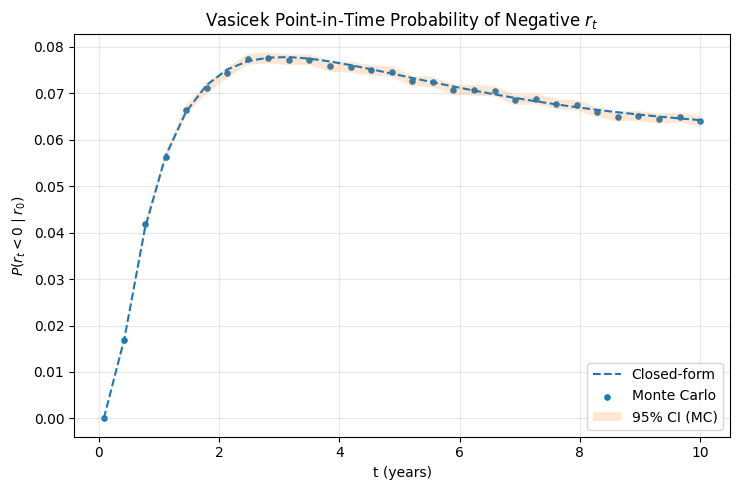

In [1]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, exp, erf

# compute exact Vasicek transition parameters
def vasicek_step_params(a, sigma, dt):
    """
    Return (ed, sd) for one exact Vasicek step of size dt.
    ed = exp(-a*dt), sd = sqrt( (sigma^2 / (2a)) * (1 - ed^2) )

    Args:
    -----
        a (float)    : mean-reversion speed
        sigma (float): volatility
        dt (float)   : time step

    Returns:
    --------
        (ed, sd) (tuple[float, float]): decay factor and step standard deviation
    """
    # decay factor and step variance from exact OU transition
    ed = np.exp(-a * dt)
    var = (sigma**2 / (2.0 * a)) * (1.0 - ed**2)

    # standard deviation for step
    sd = np.sqrt(var)

    # return tuple
    return ed, sd


# simulate r_T via exact one-step transition
def simulate_rT_point(a, b, sigma, r0, T, n_paths, seed=0):
    """
    Simulate the terminal short rate r_T from the exact Vasicek marginal.

    Args:
    -----
        a (float)        : mean-reversion speed
        b (float)        : long-run mean level
        sigma (float)    : volatility
        r0 (float)       : initial short rate
        T (float)        : horizon in years
        n_paths (int)    : number of simulated paths
        seed (int, opt)  : RNG seed

    Returns:
    --------
        rT (np.ndarray): shape (n_paths,), simulated terminal rates
    """
    # set seed
    rng = np.random.default_rng(seed)

    # extract exact one-step parameters at horizon T
    ed, sd = vasicek_step_params(a, sigma, T)

    # draw standard normals and form exact marginal
    z = rng.standard_normal(n_paths)

    # construct paths
    rT = b + (r0 - b) * ed + sd * z

    # return array of paths
    return rT


# compute closed-form mean and variance at time t
def vasicek_moments(a, b, sigma, r0, t):
    """
    Compute conditional mean and variance of r_t | r_0 under Vasicek.

    Args:
    -----
        a (float)     : mean-reversion speed
        b (float)     : long-run mean level
        sigma (float) : volatility
        r0 (float)    : initial short rate
        t (float)     : time in years

    Returns:
    --------
        (m, v) (tuple[float, float]): conditional mean and variance at time t
    """
    # conditional mean from OU solution
    m = b + (r0 - b) * np.exp(-a * t)

    # conditional variance
    v = (sigma**2 / (2.0 * a)) * (1.0 - np.exp(-2.0 * a * t))

    # return moments
    return m, v


# compute closed-form point-in-time probability
def prob_negative_point_closed_form(a, b, sigma, r0, t):
    """
    Compute P(r_t < 0 | r_0) using the Gaussian transition law.

    Args:
    -----
        a (float)     : mean-reversion speed
        b (float)     : long-run mean level
        sigma (float) : volatility
        r0 (float)    : initial short rate
        t (float)     : time in years

    Returns:
    --------
        prob (float): probability that r_t is negative at time t
    """
    # get conditional mean and variance
    m, v = vasicek_moments(a, b, sigma, r0, t)

    # standardize
    x = (-m) / sqrt(v)

    # evaluate normal CDF
    Phi = 0.5 * (1.0 + erf(x / sqrt(2.0)))

    return Phi


# estimate point-in-time probability via Monte Carlo
def prob_negative_point_mc(a, b, sigma, r0, t, n_paths, seed=0):
    """
    Estimate P(r_t < 0 | r_0) via Monte Carlo using the exact marginal.

    Args:
    -----
        a (float)        : mean-reversion speed
        b (float)        : long-run mean level
        sigma (float)    : volatility
        r0 (float)       : initial short rate
        t (float)        : time in years
        n_paths (int)    : number of simulated paths
        seed (int, opt)  : RNG seed

    Returns:
    --------
        (p_hat, (lo, hi)) (tuple[float, tuple[float, float]]):
            p_hat is the Monte Carlo estimate,
            (lo, hi) is a 95% Wald confidence interval for p_hat
    """
    # simulate the terminal short rate
    rT = simulate_rT_point(a, b, sigma, r0, t, n_paths, seed=seed)

    # form indicator and compute the proportion
    p_hat = np.mean(rT < 0.0)

    # compute 95% Wald CI for a sample proportion
    se = np.sqrt(max(p_hat * (1.0 - p_hat), 1e-16) / len(rT))
    lo = p_hat - 1.96 * se
    hi = p_hat + 1.96 * se

    # return estimate and CI
    return p_hat, (lo, hi)


# parameters and grid for the demonstration
a = 0.30
b = 0.02
sigma = 0.01
r0 = 0.012
n_paths = 200_000
t_grid = np.linspace(1/12, 10.0, 30)

# compute both MC and closed-form probabilities across t
p_mc, p_lo, p_hi, p_cf = [], [], [], []

# loop through time grid
for i, t in enumerate(t_grid):

    # closed-form probability at time t
    p_cf.append(prob_negative_point_closed_form(a, b, sigma, r0, t))

    # Monte Carlo estimate and its 95% CI
    p_hat, (lo, hi) = prob_negative_point_mc(a, b, sigma, r0, t,
                                             n_paths=n_paths, seed=123 + i)

    # capture estimate and CI endpoints
    p_mc.append(p_hat)
    p_lo.append(lo)
    p_hi.append(hi)


# convert to arrays for plotting
p_mc = np.array(p_mc)
p_cf = np.array(p_cf)
p_lo = np.array(p_lo)
p_hi = np.array(p_hi)


# plot probability vs time using closed form
plt.figure(figsize=(7.5, 5))
plt.plot(t_grid, p_cf, label="Closed-form", linestyle="--")

# MC estimates w/CI
plt.scatter(t_grid, p_mc, s=14, label="Monte Carlo")
plt.fill_between(t_grid, p_lo, p_hi, alpha=0.18, label="95% CI (MC)")

# title, labels
plt.title(r"Vasicek Point-in-Time Probability of Negative $r_t$")
plt.xlabel("t (years)")
plt.ylabel(r"$P(r_t < 0 \mid r_0)$")

# legend, grid, plot
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Simulation results match the closed form. Sampling error from the MC process is minimal, hence the narrow band. I observe the following. Probability at first is increasing, reflecting the short rate diffusing around its mean and conditional variance increasing with t, so rates can wander into negative territory. The curve peaks around 2-3 years (for given parameters) and declines modestly. At small t, volatility dominates, but at large t, mean reversion takes over and the distribution of $r_t$ converges to the stationary Gaussian. Thus the probability of a negative rate converges to the stationary tail probability (given the parameters, this is about 6.06%, consistent with the plot).

Despite starting from a positive rate, there is still a non-zero risk of negative rates due to the diffusion term. That risk stabilizes over time and is a function of mean vs. volatility vs. mean-reversion strength, which I examine next.

## Probability as a Function of Parameters

Using the stationary distribution, I compute probability of negative $r_t$ as a function of process parameters $a, b, \sigma$. E.g. for $a=0.30, b = 0.02,\sigma = 0.01:$

\begin{align*}
\mathbb{P}(r_\infty < 0) &= \Phi\! \left( -\,\frac{ b \sqrt{2 a} }{ \sigma } \right)\\
&= \Phi\!\left( -\,\frac{0.02 \sqrt{0.60}}{0.01} \right)
\end{align*}

I expect that probability is:

- decreasing in mean-reversion speed $a$

- decreasing in long-run mean $b$

- increasing in vol $\sigma$

Closed-form stationary probability: 0.060668
Monte Carlo stationary probability: 0.061418


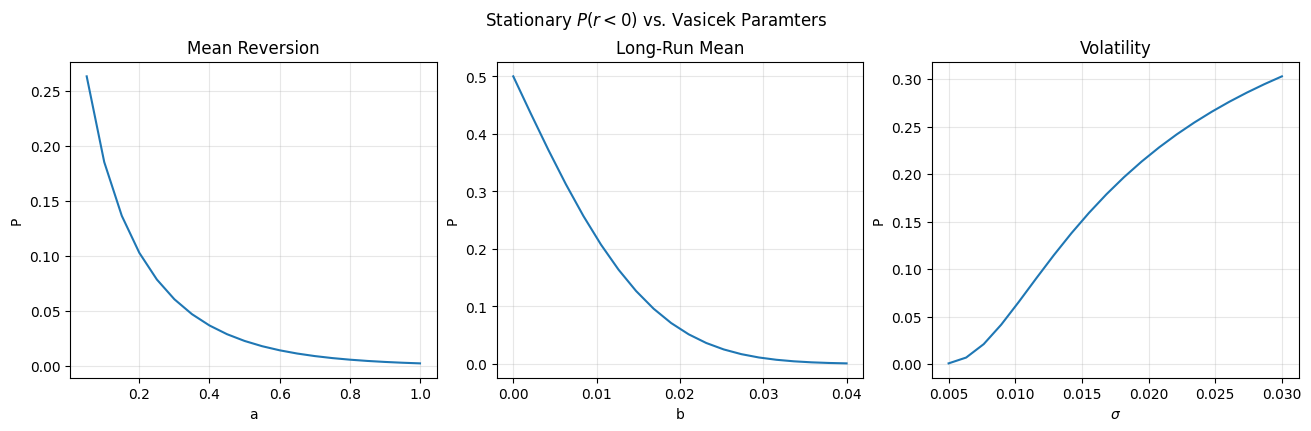

In [2]:
# stationary closed-form probability function
def prob_negative_stationary(a, b, sigma):
    """
    Return P(r_infty < 0) under Vasicek stationarity:
    Phi( - b * sqrt(2a) / sigma ).

    Args:
    -----
        a (float)     : mean-reversion speed
        b (float)     : long-run mean level
        sigma (float) : volatility

    Returns:
    --------
        prob (float): stationary probability that r < 0
    """
    # standardize
    x = - b * sqrt(2.0 * a) / sigma

    # evaluate normal CDF
    Phi = 0.5 * (1.0 + erf(x / sqrt(2.0)))

    return Phi


# simulate near-stationary samples via long-run evolution
def simulate_stationary_mc(a, b, sigma, r0, T_large, n_paths, seed=0):
    """
    Evolve the process for horizon T_large and return r_T; with T_large >> 1/a
    this approximates draws from the stationary distribution.

    Args:
    -----
        a (float)        : mean-reversion speed
        b (float)        : long-run mean level
        sigma (float)    : volatility
        r0 (float)       : initial short rate
        T_large (float)  : long horizon in years (use >> 1/a)
        n_paths (int)    : number of simulated paths
        seed (int, opt)  : RNG seed

    Returns:
    --------
        rT (np.ndarray): shape (n_paths,), approximate stationary draws
    """
    # set seed
    rng = np.random.default_rng(seed)

    # exact OU decay and step standard deviation at horizon T_large
    ed = np.exp(-a * T_large)
    var = (sigma**2 / (2.0 * a)) * (1.0 - ed**2)
    sd = np.sqrt(var)

    # draw standard normals
    z = rng.standard_normal(n_paths)

    # map through exact one step marginal
    rT = b + (r0 - b) * ed + sd * z

    return rT


# base parameters
a0, b0, s0, r0 = 0.30, 0.02, 0.01, 0.012
T_large = 20.0
n_paths = 400_000


# confirm stationary probability via closed form and Monte Carlo
p_stat_cf = prob_negative_stationary(a0, b0, s0)
rT = simulate_stationary_mc(a0, b0, s0, r0, T_large, n_paths, seed=42)
p_stat_mc = np.mean(rT < 0.0)


# compare estimates
print("Closed-form stationary probability:", np.round(p_stat_cf, 6))
print("Monte Carlo stationary probability:", np.round(p_stat_mc, 6))


# construct parameter grids for sensitivity plots
a_vals = np.linspace(0.05, 1.0, 20)
b_vals = np.linspace(0.0, 0.04, 20)
s_vals = np.linspace(0.005, 0.03, 20)


# evaluate stationary probabilities across grids
p_a = [prob_negative_stationary(a, b0, s0) for a in a_vals]
p_b = [prob_negative_stationary(a0, b, s0) for b in b_vals]
p_s = [prob_negative_stationary(a0, b0, s) for s in s_vals]


# set subplot grid
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)

# plot probability vs a
axes[0].plot(a_vals, p_a)
axes[0].set_title("Mean Reversion")
axes[0].set_xlabel("a")
axes[0].set_ylabel("P")
axes[0].grid(alpha=0.3)

# plot probability vs b
axes[1].plot(b_vals, p_b)
axes[1].set_title("Long-Run Mean")
axes[1].set_xlabel("b")
axes[1].set_ylabel("P")
axes[1].grid(alpha=0.3)

# plot probability vs sigma
axes[2].plot(s_vals, p_s)
axes[2].set_title("Volatility")
axes[2].set_xlabel(r"$\sigma$")
axes[2].set_ylabel("P")
axes[2].grid(alpha=0.3)

# plot
plt.suptitle(r"Stationary $P(r<0)$ vs. Vasicek Paramters")
plt.show()

The plots for the mean reversion and long-run mean parameters display the expected convexity. At a low $a$, a small increase sharply reduces negative-rate probability. At high $a$, the distribution is already tight, so further mean reversion barely moves the tail probability. Volatility $\sigma$ has the opposite effect as $a$. Increasing $\sigma$ widens the distribution, increasing tail mass. When $\sigma$ is very small, a small increase causes a huge jump in variance, thus the tail probability explodes. Economic intuition is as follows:

- faster mean reversion means the rate is anchored near long-run mean $b$, so it doesn’t wander into negative territory often.

- a higher long-run mean simply puts the typical rate further above zero.

- higher volatility makes extreme events more likely, including negative $r$.

Tail probabability is clearly non-linear in parameters. However, once parameters are far from zero, the probability of negative rates stabilizes.

## Pathwise Probability

The final probability is of the event that the short rate is ever negative at any time before some $T$, the pathwise probability:

$$
q_T = P(\min_{0 \le s \le T} r_{s}<0 |r_0)
$$

which depends on the entire path history. If there is a closed form expression, I can't find it and certainly can't derive it. Instead, reformulate the event:

\begin{align*}
\tau_0 &= \inf\{ t \ge 0 : r_t \le 0 \}, \\
q_T &= \mathbb{P}\big( \tau_0 \le T \mid r_0 \big).
\end{align*}

and estimate the CDF using Monte Carlo by simulating many paths, and testing whether each ever crosses 0 using the estimator:

$$
\hat{q}_{T} = \frac{1}{N}\sum_{i=1}^{N}\bf{1}\big\{ \min_{0 \le s \le T} r^{(i)}_{s}<0 \big\}
$$

The procedure is as follows.

1. Choose time grid $0=t_{0}<...<t_{M}=T$

2. For each path, simulate $r_{tk}$

3. Track indicator for every hit

4. Estimate $\hat{q}_T$ and compute SE

There's a wrinkle. Simulating a diffusion on a grid shows only the endpoints, e.g. $r_{tk}$ and $r_{tk+1}$. The path could've dipped below 0 in between, thus I use a Brownian bridge to get the probability that the interpolating path crosses 0 during the step. For standard Brownian motion with variance $\text{Var}(X_{t+\Delta} - X_{t})= \sigma^{2}_{\Delta}$,

$$
P(\min_{s \in [t, t+\Delta]} \text{bridge}(s) \le 0 | X_{t} = x > 0, X_{t+\Delta}=y > 0) = \text{exp}(\frac{-2xy}{\sigma^{2}_{\Delta}})
$$

I simply plug in the endpoints and the step variance. If either end point is 0 or negative, the indicator hits. If both are positive, flip a Bernoulli with crossing probability:

$$
\text{exp}\big( \frac{-2r_{t}r_{t+\Delta}}{\text{Var}(r_{t+\Delta}|r_{t})} \big)
$$

In [3]:
# advance collection of paths by 1 step
def vasicek_exact_step(a, b, sigma, r, dt, rng):
    """
    Advance a vector of short rates by one exact Vasicek step.

    Args:
    -----
        a (float)          : mean-reversion speed
        b (float)          : long-run mean level
        sigma (float)      : volatility
        r (np.ndarray)     : current short rates, shape (n_alive,)
        dt (float)         : time step
        rng (np.random.Generator): RNG

    Returns:
    --------
        (r_next, step_var) (tuple[np.ndarray, float]):
            r_next is next-step short rates,
            step_var is the (scalar) conditional variance for the step
    """
    # exact step parameters
    ed, sd = vasicek_step_params(a, sigma, dt)

    # draw standard normals for alive paths
    z = rng.standard_normal(len(r))

    # propagate process
    r_next = b + (r - b) * ed + sd * z

    # return next values and scalar step variance
    return r_next, sd * sd


# estimate ever-hit probability with Brownian-bridge crossing proxy
def first_passage_prob_bridge(a, b, sigma, r0, T, dt, n_paths, seed=0):
    """
    Estimate q_T = P(min_{0<=t<=T} r_t < 0) using exact steps + a
    Brownian-bridge crossing probability approximation on each step.

    Args:
    -----
        a (float)        : mean-reversion speed
        b (float)        : long-run mean level
        sigma (float)    : volatility
        r0 (float)       : initial short rate
        T (float)        : horizon in years
        dt (float)       : simulation time step
        n_paths (int)    : number of Monte Carlo paths
        seed (int, opt)  : RNG seed

    Returns:
    --------
        (q_hat, se, (lo, hi)) (tuple[float, float, tuple[float, float]]):
            q_hat is the hit probability estimate,
            se is the Bernoulli standard error,
            (lo, hi) is the 95% Wald confidence interval
    """
    # setup RNG and iteration counts
    rng = np.random.default_rng(seed)
    n_steps = int(np.ceil(T / dt))

    # initialize path states and vectors
    r = np.full(n_paths, r0, dtype=float)
    alive = np.ones(n_paths, dtype=bool)
    hit = np.zeros(n_paths, dtype=bool)

    # main simulation loop
    for _ in range(n_steps):

        # pick indices of paths that have not hit yet
        idx = np.where(alive)[0]

        # stop if all paths have hit
        if idx.size == 0:
            break

        # slice current alive values
        r_alive = r[idx]

        # propagate one exact step
        r_next, step_var = vasicek_exact_step(a, b, sigma, r_alive, dt, rng)

        # direct hits if either endpoint nonpositive
        step_hit = (r_alive <= 0.0) | (r_next <= 0.0)

        # boolean mask for positive to positive steps
        mask = (~step_hit) & (r_alive > 0.0) & (r_next > 0.0)

        if np.any(mask):

            # compute bridge crossing probability
            p_cross = np.exp(-2.0 * r_alive[mask] * r_next[mask] / step_var)
            u = rng.random(mask.sum())
            step_hit[mask] = u < p_cross

        # mark hits and update which paths remain alive
        hit[idx] |= step_hit
        alive[idx[step_hit]] = False

        # write next step values back
        r[idx] = r_next

    # form Bernoulli estimator
    q_hat = hit.mean()

    # compute SE and CI
    se = np.sqrt(max(q_hat * (1.0 - q_hat), 1e-16) / n_paths)
    lo = q_hat - 1.96 * se
    hi = q_hat + 1.96 * se

    # return estimate, se, CI
    return q_hat, se, (lo, hi)


# sweep over grid and assemble results
def build_results_table(a_vals, sigma_vals, T_vals, b, r0, dt, n_paths, seed=0):
    """
    Compute ever-hit probability across parameter grids and return a dataframe.

    Args:
    -----
        a_vals (list[float])    : grid for mean-reversion speed
        sigma_vals (list[float]): grid for volatility
        T_vals (list[float])    : horizons to evaluate
        b (float)               : long-run mean level
        r0 (float)              : initial short rate
        dt (float)              : simulation step
        n_paths (int)           : number of paths per configuration
        seed (int, opt)         : RNG seed baseline

    Returns:
    --------
        df (pd.DataFrame): table with columns
            [a, sigma, T, q_hat, se, ci_lo, ci_hi, n_paths, dt]
    """
    # list to collect results
    rows = []

    # iterate over parameter grid
    k = 0
    for a in a_vals:
        for sigma in sigma_vals:
            for T in T_vals:

                # choose reproducible seed per config
                cfg_seed = seed + 37 * k

                # estimate ever hit probability
                q_hat, se, (lo, hi) = first_passage_prob_bridge(
                    a, b, sigma, r0, T, dt, n_paths, seed=cfg_seed
                )

                # append row
                rows.append({"a": a, "sigma": sigma, "T": T, "q_hat": q_hat,
                             "se": se, "ci_lo": lo, "ci_hi": hi,
                             "n_paths": n_paths, "dt": dt})

                # increment counter
                k += 1

    # store results as dataframe
    df = pd.DataFrame(rows)

    # sort rows for readability
    df = df.sort_values(["T", "a", "sigma"]).reset_index(drop=True)

    return df


# baseline model parameters
b = 0.02
r0 = 0.012


# grids and simulation controls
a_vals = [0.15, 0.30, 0.60]
sigma_vals = [0.0075, 0.0100, 0.0150]
T_vals = [1.0, 2.0, 3.0, 4.0, 5.0]
dt = 1.0 / 252.0
n_paths = 30000
seed = 1776


# build results
results_df = build_results_table(a_vals, sigma_vals, T_vals, b, r0, dt, n_paths,
                                 seed)

# check results
display(results_df.round(6).head(6))


,a,sigma,T,q_hat,se,ci_lo,ci_hi,n_paths,dt
0,0.15,0.0075,1.0,0.073300,0.001505,0.070351,0.076249,30000,0.003968
1,0.15,0.0100,1.0,0.185900,0.002246,0.181498,0.190302,30000,0.003968
2,0.15,0.0150,1.0,0.389833,0.002816,0.384314,0.395352,30000,0.003968
3,0.30,0.0075,1.0,0.044733,0.001193,0.042394,0.047073,30000,0.003968
4,0.30,0.0100,1.0,0.148633,0.002054,0.144608,0.152659,30000,0.003968
5,0.30,0.0150,1.0,0.357867,0.002768,0.352442,0.363291,30000,0.003968


Results are as expected. For a fixed $a$ and $T$, higher volatility raises probability of hitting zero. For fixed volatility and $T$, stronger mean reversion lowers hit probability. Hit probability is increasing in $T$. CIs generally are tight due to the large sample size.